In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [5]:
# hyperparameters so I can control how network learns
batch_size = 64
learning_rate = 0.001
num_epochs = 10

In [6]:
# Fashion MNIST images are 28x28 grayscale images
# We will convert images to tensors
# Will also normalize them to improve training performance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Loading training data
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# Loading test data
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

# just data loaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.5MB/s]


# Defining the Deep Feedforward Neural Network
Architecture:

Input: 28 × 28 = 784

Hidden layers: 3 layers

Activation: ReLU

Output: 10 classes

In [7]:
class DeepFeedForwardNN(nn.Module):
    def __init__(self):
        super(DeepFeedForwardNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


In [8]:
#initializing model, loss and optimizers

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepFeedForwardNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [9]:
# training loop
# we will be tracking training loss and accuracy
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()

    correct = 0
    total = 0
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Accuracy calculation
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {epoch_loss:.4f}, "
          f"Accuracy: {epoch_accuracy:.4f}")

Epoch [1/10], Loss: 0.5025, Accuracy: 0.8144
Epoch [2/10], Loss: 0.3744, Accuracy: 0.8617
Epoch [3/10], Loss: 0.3353, Accuracy: 0.8760
Epoch [4/10], Loss: 0.3091, Accuracy: 0.8850
Epoch [5/10], Loss: 0.2860, Accuracy: 0.8939
Epoch [6/10], Loss: 0.2711, Accuracy: 0.8991
Epoch [7/10], Loss: 0.2566, Accuracy: 0.9033
Epoch [8/10], Loss: 0.2416, Accuracy: 0.9095
Epoch [9/10], Loss: 0.2321, Accuracy: 0.9122
Epoch [10/10], Loss: 0.2211, Accuracy: 0.9162


In [10]:
# evaluating on the test data
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f"\nTest Accuracy: {test_accuracy:.4f}")



Test Accuracy: 0.8820


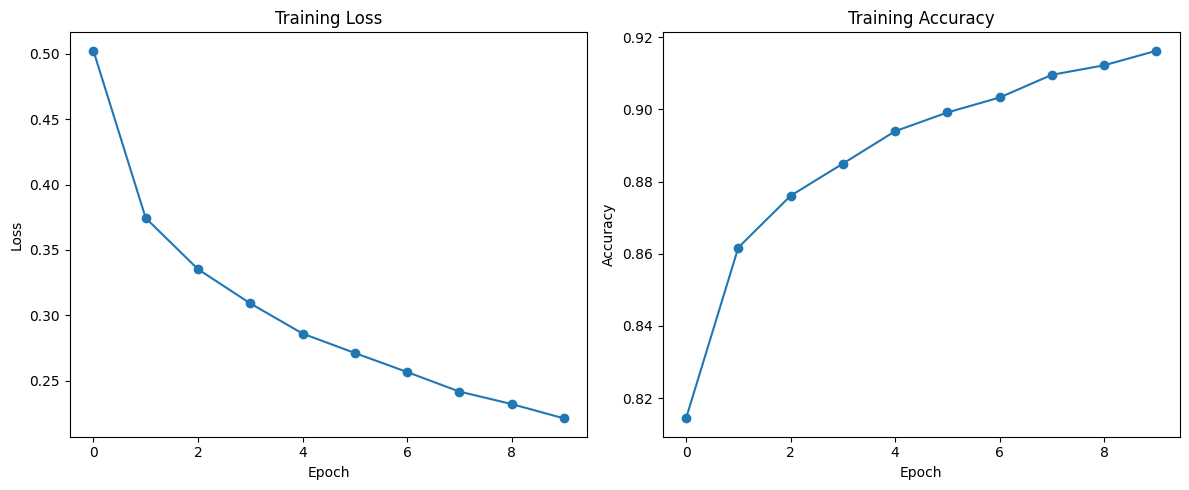

In [11]:
#visualization
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()


# Advanced task 1: Experimenting with Network Depth and Width

In [12]:
# I will be experimenting by manipulating number of layers and neurons
# to do that, There will be a flexible FNN first
class FlexibleFeedForwardNN(nn.Module):
    def __init__(self, hidden_layers, hidden_units):
        """
        hidden_layers: number of hidden layers
        hidden_units: neurons per hidden layer
        """
        super().__init__()

        layers = []
        input_size = 784

        for _ in range(hidden_layers):
            layers.append(nn.Linear(input_size, hidden_units))
            layers.append(nn.ReLU())
            input_size = hidden_units

        layers.append(nn.Linear(hidden_units, 10))  # Output layer

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [13]:
# Training and evaluation function so that I can reuse it
def train_and_evaluate(model, train_loader, test_loader, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.view(images.size(0), -1).to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Evaluation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images = images.view(images.size(0), -1).to(device)
                labels = labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracies.append(correct / total)

    return train_losses, test_accuracies

In [14]:
# running experiments with different layers and neurons
configs = [
    (1, 128),
    (3, 256),
    (5, 256)
]

results = {}

for layers, units in configs:
    model = FlexibleFeedForwardNN(layers, units).to(device)
    losses, accs = train_and_evaluate(model, train_loader, test_loader)
    results[f"{layers}_layers"] = (losses, accs)


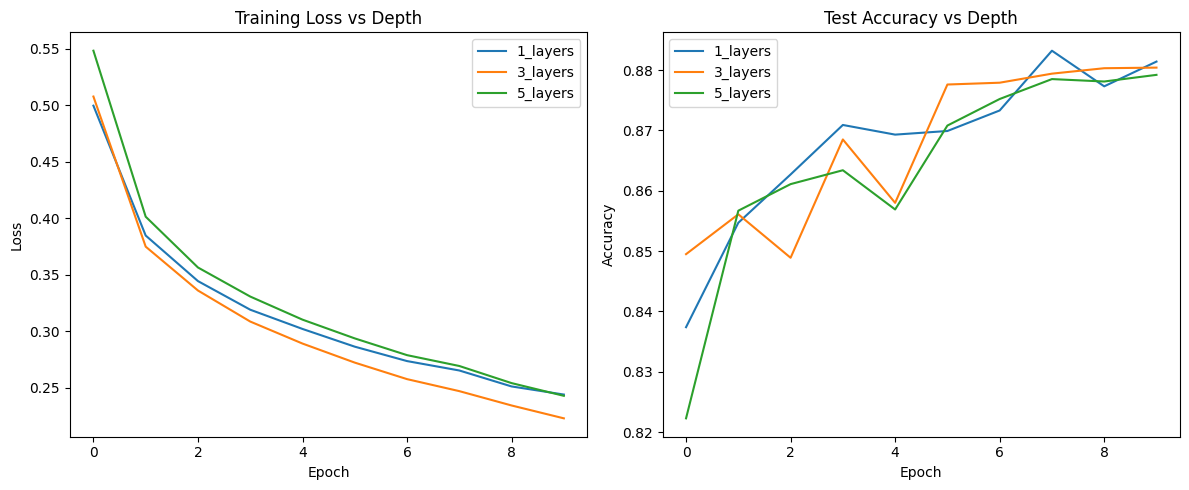

In [23]:
# visualization
plt.figure(figsize=(12, 5))

# Training loss comparison
plt.subplot(1, 2, 1)
for key, (losses, _) in results.items():
    plt.plot(losses, label=key)
plt.title("Training Loss vs Depth")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Test accuracy comparison
plt.subplot(1, 2, 2)
for key, (_, accs) in results.items():
    plt.plot(accs, label=key)
plt.title("Test Accuracy vs Depth")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

By experimenting with Depth and Width of the neural network we can see that:
- 1 layer was faster but it underfitted
- 3 layers were a balanced approached
- 5 layers were slower but it performed well

# Advanced Task 2: Experimenting with different Activation Functions

In [15]:
# just a reusable function to set the activation function
def get_activation(name):
    if name == "relu":
        return nn.ReLU()
    elif name == "sigmoid":
        return nn.Sigmoid()
    elif name == "tanh":
        return nn.Tanh()
    elif name == "leaky_relu":
        return nn.LeakyReLU(0.01)

In [16]:
class ActivationNN(nn.Module):
    def __init__(self, activation):
        super().__init__()
        act = get_activation(activation)

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            act,
            nn.Linear(256, 128),
            act,
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)


In [17]:
# training with different activation functions and storing the results
activations = ["relu", "sigmoid", "tanh", "leaky_relu"]
activation_results = {}

for act in activations:
    model = ActivationNN(act).to(device)
    losses, accs = train_and_evaluate(model, train_loader, test_loader)
    activation_results[act] = (losses, accs)

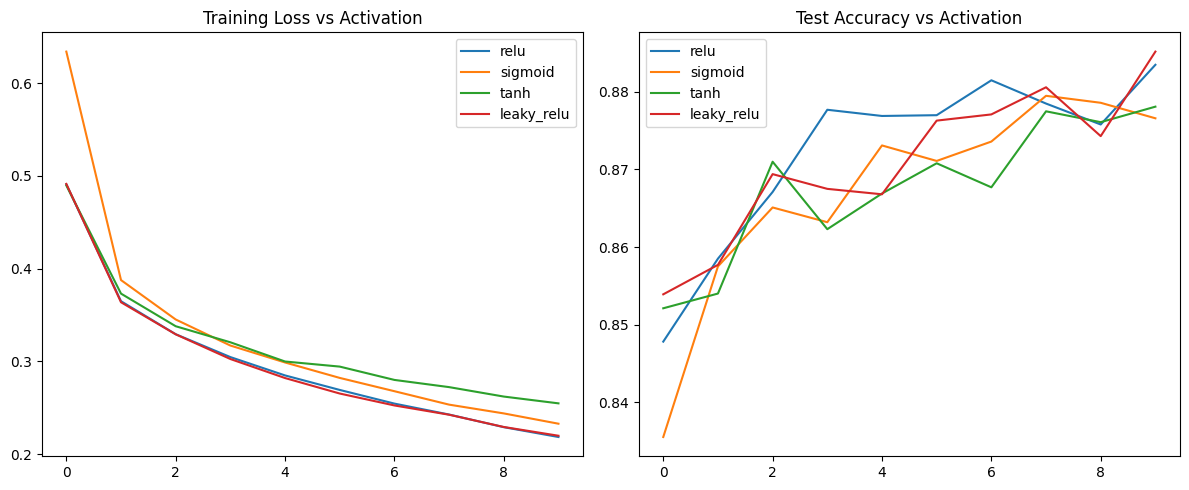

In [18]:
# Plotting the comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for act, (losses, _) in activation_results.items():
    plt.plot(losses, label=act)
plt.title("Training Loss vs Activation")
plt.legend()

plt.subplot(1, 2, 2)
for act, (_, accs) in activation_results.items():
    plt.plot(accs, label=act)
plt.title("Test Accuracy vs Activation")
plt.legend()

plt.tight_layout()
plt.show()

What did I learn
- Relu wins among all because it is faster (doesn't have any big calculations) and also it doesn't have the vanishing gradient problem.
- Sigmoid causes vanishing gradient problem, because as we move forward in a deep neural network, it will make the value of neurons' output smaller and smaller. At one point, we won't be able to extract any information.

# Advanced Task 3: Visualization of Hidden Layer Activations

In [19]:
activations = {}

def get_hook(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

In [20]:
model = ActivationNN("relu").to(device)

model.model[0].register_forward_hook(get_hook("Layer1"))
model.model[2].register_forward_hook(get_hook("Layer2"))


In [21]:
model.eval()
images, _ = next(iter(test_loader))
images = images[:5].view(5, -1).to(device)

with torch.no_grad():
    model(images)

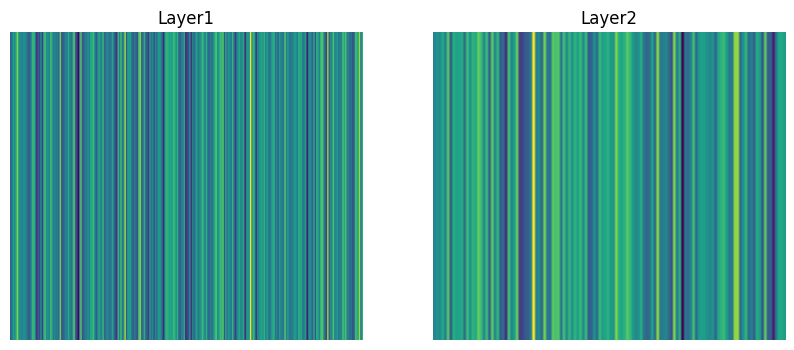

In [22]:
plt.figure(figsize=(10, 4))

for i, (name, act) in enumerate(activations.items()):
    plt.subplot(1, len(activations), i + 1)
    plt.imshow(act[0].cpu().view(1, -1), aspect="auto")
    plt.title(name)
    plt.axis("off")

plt.show()